<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/main/Document_Processing_with_PaddleOCR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dcument Processing with PaddleOCR

In [ ]:
# Install all functionalities, such as document parsing, document understanding,
# document translation, and key information extraction
!pip install "paddleocr[all]"

In [ ]:
# You need to install paddlepaddle superatedly appart from paddlleocr othe
# or you could just !pip install "paddleocr[all]@git+https://github.com/PaddlePaddle/PaddleOCR.git"
# Make sure the paddle version matches to paddleOCR version
!pip install paddlepaddle==3.2.0

In [ ]:
# Make import superately make sure the version matches
from paddleocr import PaddleOCR

In [4]:
from PIL import Image
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colormaps
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain.agents import AgentExecutor
import csv

In [5]:
import os
from dotenv import load_dotenv
# Load environment variable from .env
_ = load_dotenv(override=True)

## 1. PaddleOCR Basic

In [ ]:
# Initialize english OCR model
ocr = PaddleOCR(lang='en')

In [ ]:
from IPython.display import display

image_path = 'noisy_img.jpeg'
img = Image.open(image_path)
display(img)

In [8]:
import paddleocr
import paddle

In [9]:
print("paddleocr version: ", paddleocr.__version__)
print("paddle version: ", paddle.__version__)


paddleocr version:  3.4.0
paddle version:  3.2.0


In [10]:
# Run OCR
result = ocr.predict(image_path)

In [ ]:
page = result[0]
texts = page['rec_texts'] # recognized text strings
scores = page['rec_scores'] # confidence scores for each text line
boxes = page['rec_polys'] # bounding box coordinates

for text, score, box in zip(texts, scores, boxes): # zip -> ties together items with the same position
  # box is a numpy array
  coords = box.astype(int).tolist() # convert to normal list of ints
  print(f"{text:25} | {score:.3f} | {coords}")

In [12]:
# Preproccess the image
img = page['doc_preprocessor_res']['output_img']

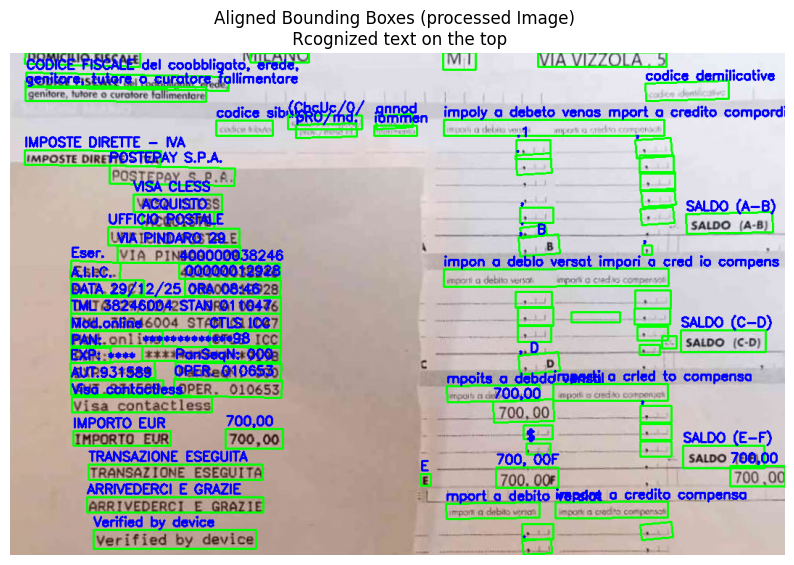

In [13]:
# display preprocessed image with all items overlayed
img_plot = img.copy()
for text, box in zip(texts, boxes):
  pts = np.array(box, dtype=int)
  cv2.polylines(img_plot, [pts], True, (0, 255, 0), 2)
  x, y = pts[0]
  cv2.putText(img_plot, text, (x, y-5),
              cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

plt.figure(figsize=(10, 16))
plt.imshow(cv2.cvtColor(img_plot, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Aligned Bounding Boxes (processed Image) \n Rcognized text on the top")
plt.show()

## 1.1 Create the PaddleOCR Tool
Turn PaddleOCR to a tool so that can be used with an agent

In [14]:
from langchain.tools import tool
import base64
from langchain_openai import ChatOpenAI
from typing import List, Dict, Any

@tool
def paddle_ocr_read_document(image_path: str) -> List[Dict[str, Any]]:
  """
  Reads an image from the given path and returns extracted text
  with bounding boxes.

  Returns a list of dictionaries, each containing:
  - 'text': the recognized text string
  - 'bbox': bounding box coordinates [x_min, y_min, x_max, y_max]
  - 'confidence': recognition confidence score (if available)
  """
  try:
    result = ocr.predict(image_path) # from paddleOCR
    page = result[0]

    texts = page['rec_texts']
    boxes = page['dt_polys']
    scores = page.get('rec_scores', [None] * len(texts))

    extracted_items = []
    for text, box, score in zip(texts, boxes, scores):
      x_coords = [point[0] for point in box]
      y_coords = [point[1] for point in box]
      bbox = [min(x_coords), min(y_coords), max(x_coords),
              max(y_coords)]

      item = {
          'text': text,
          'bbox': bbox
      }

      if score is not None:
        item['confidance'] = score
      extracted_items.append(item)
    return extracted_items
  except Exception as e:
    return [{'error': f'Error reading image {e}'}]

## 1.2 Create & Run the Agent


In [15]:
# 1. Define the list of tools
tools = [paddle_ocr_read_document]

# 2. Set up the OpenAI GPT model
if "OPENAI_API_KEY" not in os.environ:
    print("OPENAI_API_KEY environment variable is not set.")
    llm = None
else:
    llm = ChatOpenAI(
        model="gpt-5-mini",
        temperature=1
    )
    print("OpenAI Chat model initialized.")

OpenAI Chat model initialized.


In [16]:
from langchain.agents import create_tool_calling_agent
# 3. Create the OpenAI-compatible prompt
prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a helpful assistant designed to extract information "+
        "from documents. "
          "You have access to this tool: "
          "Paddle OCR tool to extract raw texts, bounding boxes for "+
          "each text and confidence score from images "
    ),
    ("user", "{input}"),
    MessagesPlaceholder(variable_name='agent_scratchpad'),
])

# 4. Create a proper tool-calling agent
agent = create_tool_calling_agent(llm, tools, prompt)

# 5. Set up the AgentExecutor to run the tool-enabled loop
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True)

In [ ]:
# Run the agent and extract information
task = """
Process the document at 'noisy_img.jpeg' and evaluate that
the total amount is correct.
"""

response = agent_executor.invoke({"input": task})

## 1.3. Run PaddleOCR on the Table and Handwriting examples

In [18]:
def run_ocr(image_path, ocr_model=ocr, show_text=True):
  display(Image.open(image_path))
  result = ocr.predict(image_path) # result from paddleOCR

  page = result[0]
  texts = page['rec_texts']
  scores = page['rec_scores']
  boxes = page['rec_polys']

  for text, score, box in zip(texts, scores, boxes):
    coords = box.astype(int).tolist()
    print(f'{text:25} | {score:.3f} | {coords}')

  # post proccessed image
  img = page['doc_preprocessor_res']['output_img']
  img_plot = img.copy()

  image_path = Path(image_path)
  output_path = image_path.with_stem(image_path.stem + '_output')
  cv2.imwrite(str(output_path), img, [cv2.IMWRITE_JPEG_QUALITY, 70])

  # Make some annotation on top using bounding box cordinate
  for text, box in zip(texts, boxes):
    pts = np.array(box, dtype=int)
    cv2.polylines(img_plot, [pts], True, (0, 255, 0), 2)
    x, y = pts[0]
    if show_text:
      cv2.putText(img_plot, text,
                  (x, y-5), cv2.FONT_HERSHEY_SIMPLEX,
                  1.0, (255, 0, 0), 2)

  plt.figure(figsize=(10, 12))
  plt.imshow(cv2.cvtColor(img_plot, cv2.COLOR_RGB2RGBA))
  plt.axis('off')

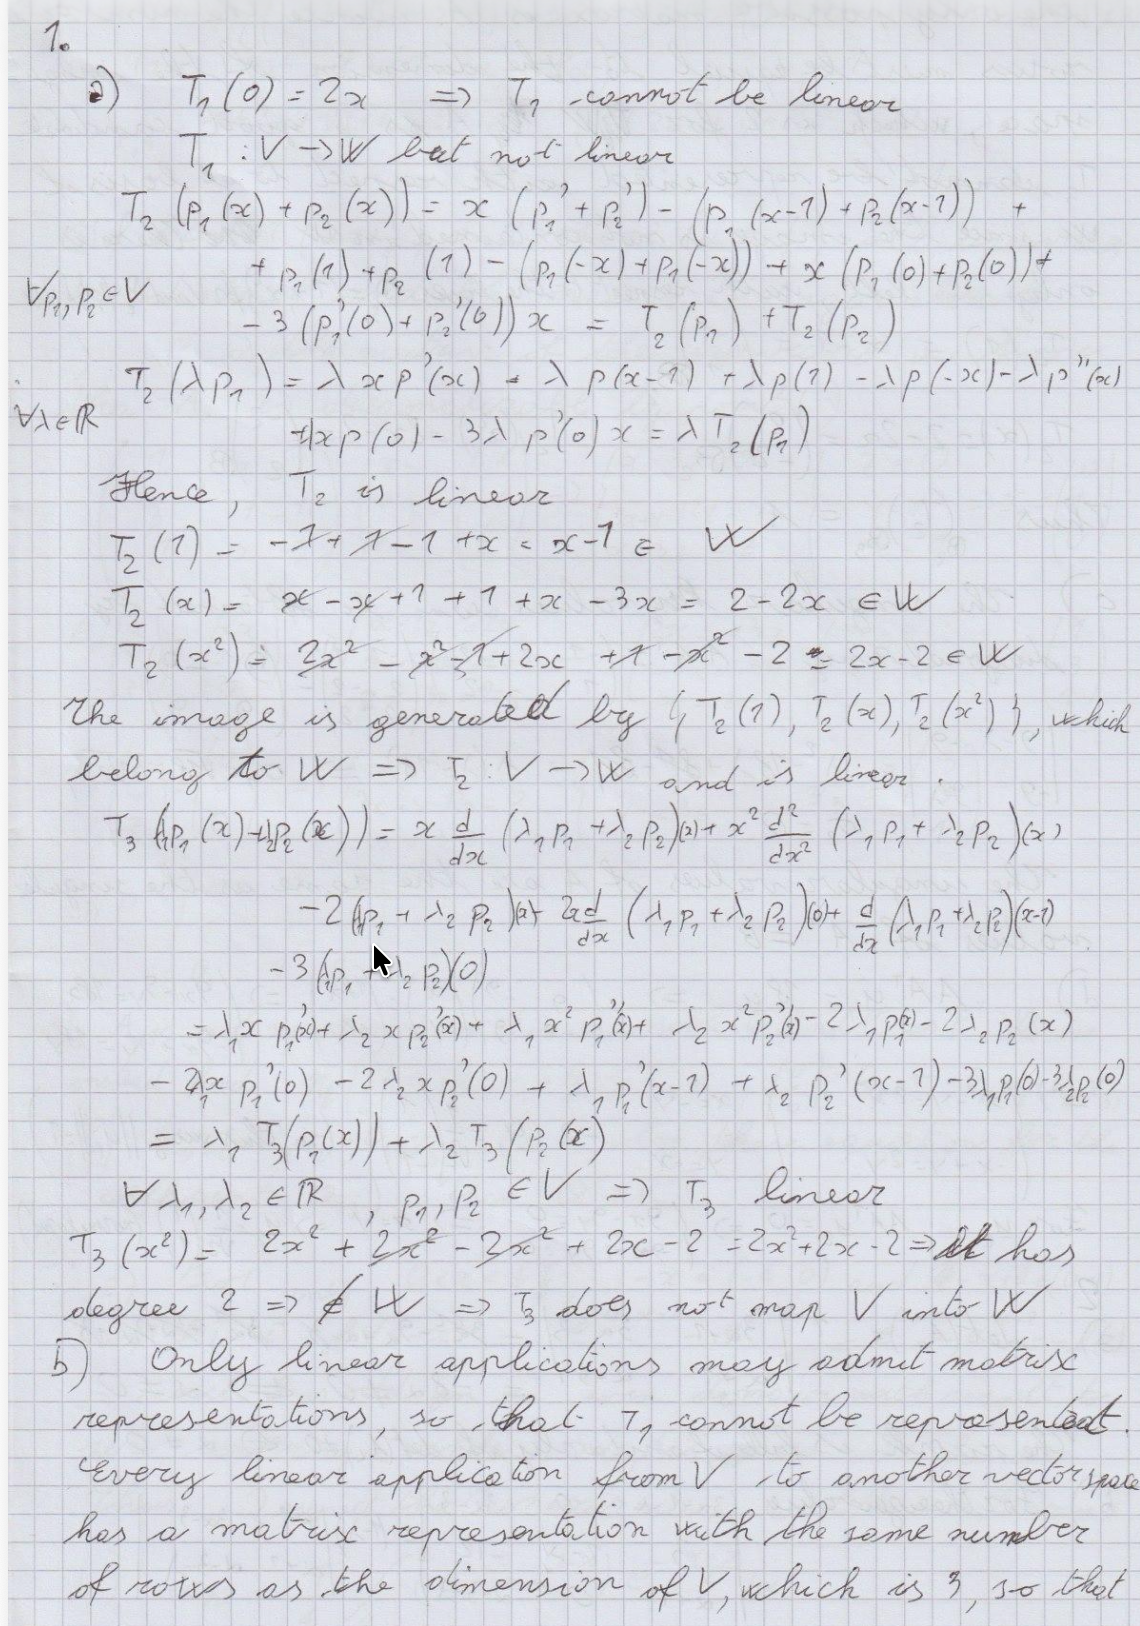

2) To (0)=2x ⇒( connt be leneoe | 0.681 | [[54, 8], [911, 23], [909, 101], [53, 85]]
T :V -→W bet not lineve   | 0.790 | [[165, 94], [677, 98], [677, 146], [164, 141]]
T2$P2(x+2x)=xP2+2)-x-7)+2(x-7) | 0.666 | [[100, 150], [1004, 135], [1005, 202], [101, 217]]
+P()+e7)-P-x)+ -x)+xP(o)+2()) | 0.676 | [[227, 212], [1068, 195], [1069, 266], [229, 282]]
VP_,PeV                   | 0.428 | [[0, 235], [147, 237], [146, 303], [0, 301]]
-3(p3()+2{())=2P+T2$      | 0.563 | [[225, 268], [909, 265], [910, 326], [225, 329]]
T2λ=x2(p(2()+xx-7+\ρ(7-1ρ->(-→1(c) | 0.618 | [[105, 332], [1140, 321], [1140, 377], [105, 389]]
VERR                      | 0.795 | [[0, 366], [93, 369], [92, 421], [0, 418]]
-1xp(0)-31p{(0)x=xT2(Pa)  | 0.560 | [[265, 370], [828, 378], [827, 456], [264, 448]]
Hene                      | 0.979 | [[83, 440], [220, 446], [218, 501], [81, 495]]
To is hinear              | 0.829 | [[275, 449], [550, 449], [550, 494], [275, 494]]
T27)=-x+x-1+x<x-7≤X       | 0.802 | [[84, 502], [794, 4

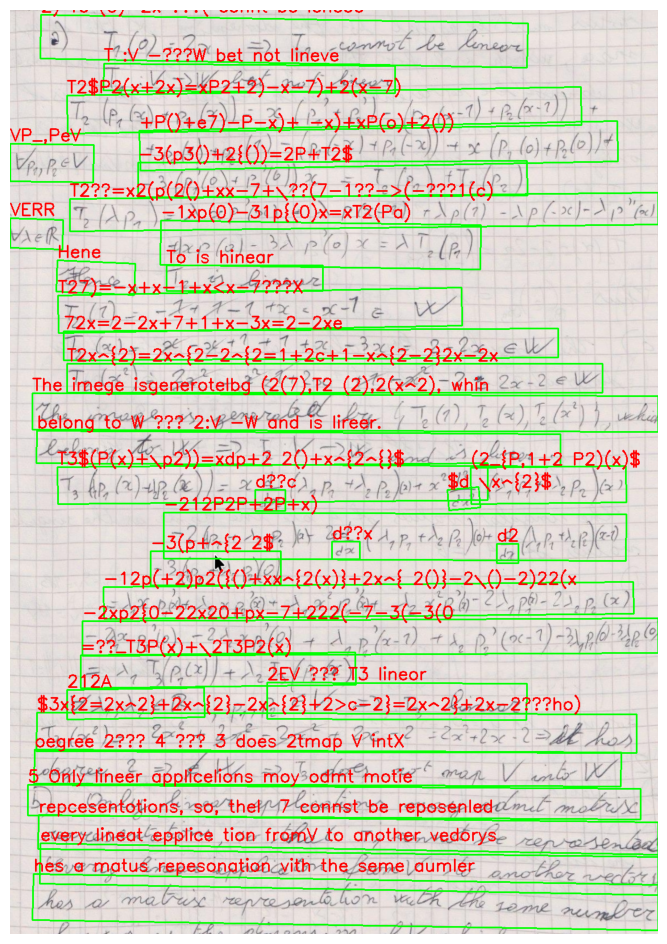

In [23]:
# image source: https://www.nature.com/articles/s41597-024-03605-5/figures/4
run_ocr('first_question.png')

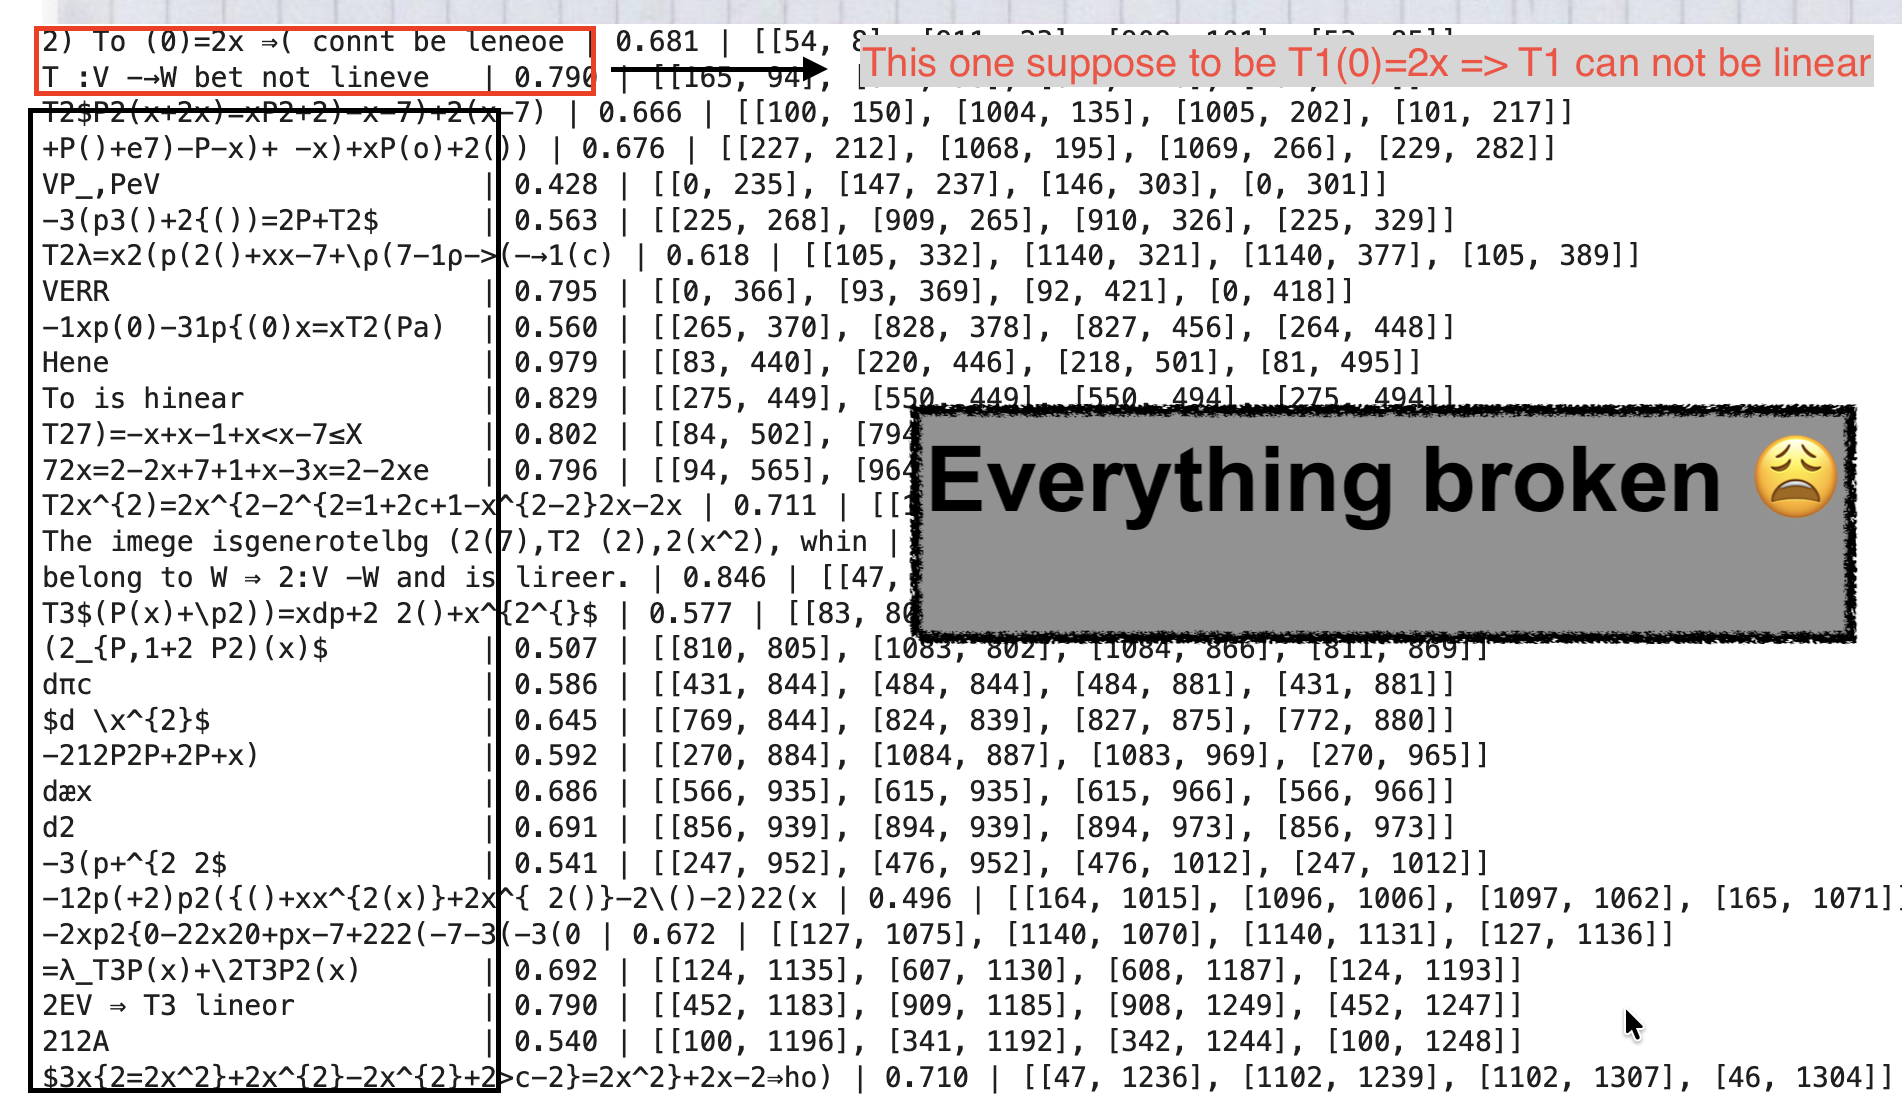

In [ ]:
task = """
Extract that why T1 is not a linear function from the first_question.png
using OCR tool.
Return a short, readable, and entry-level explanation.
"""

response = agent_executor.invoke({'input': task})

# Display results side by side
print('\n' + '_'*35 + 'LLM RESULT ' + '_'*33)
print("="*80)
print(response['output'])
print('='*80)

Let's extract some of the important part of the excersize as a json format

In [ ]:
task = """
Please process the document at "first_question.png" using OCR and
extract the following information in JSON format:
- `T2(1)`
- `T2(x)`
- `Number of rows in matrix representation`
Do not correct it.
"""

response = agent_executor.invoke({'input': task})

# Display results side by side
print('\n' + '_'*35 + 'LLM RESULT ' + '_'*33)
print("="*80)
print(response['output'])
print('='*80)


**Messed up almost every thing**
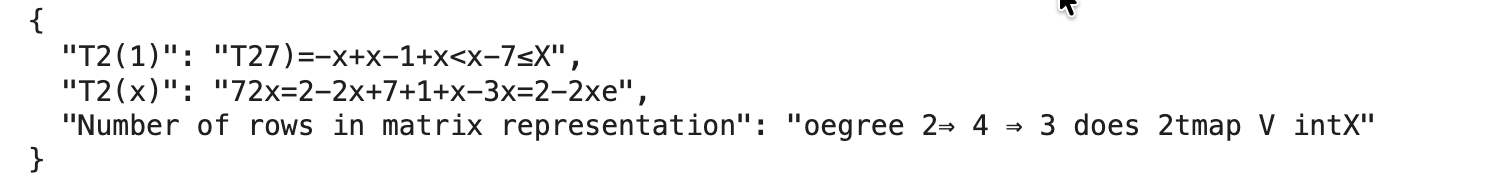

In [ ]:
task = """
Please process the document at "first_question.png" using OCR and
extract the following information in JSON format:
- `T2(1)`
- `T2(x)`
- `Number of rows in matrix representation`
Please correct it shortly and make it beginner-friendly.
"""

response = agent_executor.invoke({'input': task})

# Display results side by side
print('\n' + '_'*35 + 'LLM RESULT ' + '_'*33)
print("="*80)
print(response['output'])
print('='*80)

**It's actually correct**
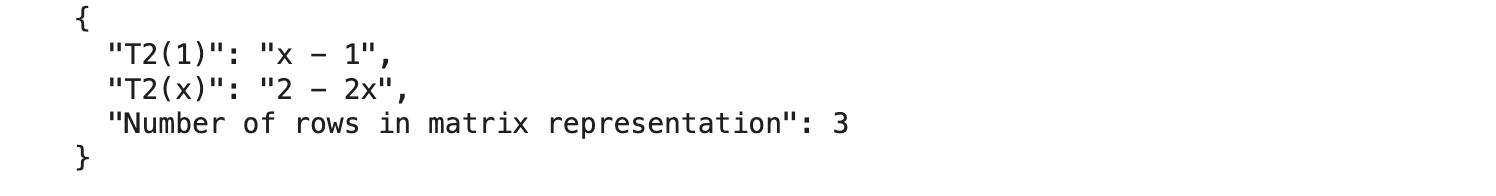

## 2. PaddleOCR Layout Detection

In [28]:
from paddleocr import LayoutDetection

In [ ]:
layout_engine = LayoutDetection()

In [30]:
def process_document(image_path):
  # Get layout regions
  layout_result = layout_engine.predict(image_path)

  # Parse the boxes
  regions = []
  for box in layout_result[0]['boxes']:
    regions.append({
        'label': box['label'],
        'score': box['score'],
        'bbox': box['coordinate']
    })

  # Sort by confidence
  regions = sorted(regions, key=lambda x: x['score'], reverse=True)

  return regions

In [61]:
regions = process_document('Technavio_Infographic.jpg')

for r in regions:
  print(f'{r['label']:20} score: {r['score']:.3f} bbox: {[int(x) for x in r['bbox']]}')

chart                score: 0.812 bbox: [26, 147, 486, 257]
chart                score: 0.725 bbox: [902, 363, 1260, 584]
chart                score: 0.623 bbox: [904, 144, 1263, 331]
figure_title         score: 0.595 bbox: [27, 98, 398, 126]
paragraph_title      score: 0.563 bbox: [27, 5, 736, 30]
image                score: 0.550 bbox: [27, 319, 496, 592]
text                 score: 0.542 bbox: [538, 120, 811, 324]
footer               score: 0.522 bbox: [837, 603, 1266, 621]


**Identifying different region on the image and labelling where they are**

In [62]:
# Create a visualization function
def visualize_layout(image_path, min_confidence=0.5):
  layout_result = layout_engine.predict(image_path)
  img= cv2.imread(image_path)
  img_plot = img.copy()

  # Get all unique labels
  labels = list(set(box['label'] for box in layout_result[0]['boxes']))

  # Generate colors dynamically from colormap
  cmap = colormaps.get_cmap('tab20')
  color_map = {}
  for i, label in enumerate(labels):
    rgba = cmap(i%20)
    # Convert to BGR (0-255) fro OpenCV
    color_map[label] = (int(rgba[2]*255), int(rgba[1]*255), int(rgba[0]*255))

  for box in layout_result[0]['boxes']:
    if box['score'] < min_confidence:
      continue

    label = box['label']
    score = box['score']
    coords = box['coordinate']

    color = color_map[label]

    x1, y1, x2, y2 = [int(c) for c in coords]
    pts = np.array([[x1, y1], [x2, y1], [x2, y2], [x1, y2]], dtype=int)

    cv2.polylines(img_plot, [pts], True, color, 2)
    text = f"{label} ({score:.2f})"
    cv2.putText(img_plot, text, (x1, y1-8), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)


  return img_plot

In [63]:
# Visualize the layout detected image
result_image = visualize_layout('Technavio_Infographic.jpg', min_confidence=0.5)


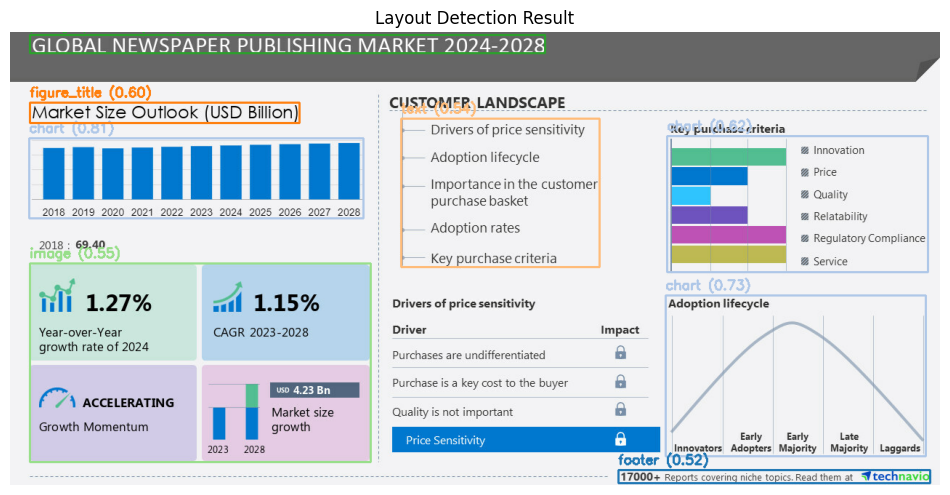

In [64]:
# Display with matplotlib
plt.figure(figsize=(12, 14))
plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Layout Detection Result')
plt.show()